In [13]:
# 환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 폰트 설정
!pip install koreanize-matplotlib -q
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 출력 옵션 (전체 컬럼 보기)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# 재현성 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 데이터 경로 (mfg_raw 네이밍 컨벤션과 동일하게)
DATA_DIR = Path('./data')
DATA_PATH = DATA_DIR / 'AdSmartABdata.csv'

In [2]:
# 파일 불러오기
adsmart_raw = pd.read_csv(DATA_PATH)
print(f"데이터 출처: https://www.kaggle.com/datasets/osuolaleemmanuel/ad-ab-testing")
print(f"불러온 날짜: 2026-07-31")  
adsmart_raw.head()

데이터 출처: https://www.kaggle.com/datasets/osuolaleemmanuel/ad-ab-testing
불러온 날짜: 2026-07-31


,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0008ef63-77a7-448b-bd1e-075f42c55e39,exposed,2020-07-10,8,Generic Smartphone,6,Chrome Mobile,0,0
1,000eabc5-17ce-4137-8efe-44734d914446,exposed,2020-07-07,10,Generic Smartphone,6,Chrome Mobile,0,0
2,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
3,00187412-2932-4542-a8ef-3633901c98d9,control,2020-07-03,15,Samsung SM-A705FN,6,Facebook,0,0
4,001a7785-d3fe-4e11-a344-c8735acacc2c,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,0


In [3]:
# 데이터 점검
print("=" * 50)
print("[기본 정보]")
print("=" * 50)
adsmart_raw.info()

print("=" * 50)
print("[중복 확인]")
print("=" * 50)
n_dup = adsmart_raw['auction_id'].duplicated().sum()
print(f"중복된 auction_id 수: {n_dup:,}")

if n_dup > 0:
    display(adsmart_raw[adsmart_raw['auction_id'].duplicated(keep=False)].sort_values('auction_id').head(10))

[기본 정보]
<class 'pandas.DataFrame'>
RangeIndex: 8077 entries, 0 to 8076
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   auction_id   8077 non-null   str  
 1   experiment   8077 non-null   str  
 2   date         8077 non-null   str  
 3   hour         8077 non-null   int64
 4   device_make  8077 non-null   str  
 5   platform_os  8077 non-null   int64
 6   browser      8077 non-null   str  
 7   yes          8077 non-null   int64
 8   no           8077 non-null   int64
dtypes: int64(4), str(5)
memory usage: 1.2 MB
[중복 확인]
중복된 auction_id 수: 0


In [4]:
# 배정 일관성 확인
print("=" * 50)
print("[배정 라벨 확인] experiment 컬럼에 이상한 값 없는지")
print("=" * 50)
print(adsmart_raw['experiment'].value_counts(dropna=False))

[배정 라벨 확인] experiment 컬럼에 이상한 값 없는지
experiment
control    4071
exposed    4006
Name: count, dtype: int64


In [5]:
# SRM 점검
from scipy.stats import chisquare

print("=" * 50)
print("[SRM 점검] control vs exposed 배정 비율")
print("=" * 50)
group_counts = adsmart_raw['experiment'].value_counts()
print(group_counts)
print()

n_total = group_counts.sum()
expected = [n_total / 2, n_total / 2]  # 50:50 배정을 의도했다고 가정
observed = group_counts.values

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
print(f"관측 비율: {observed[0]/n_total*100:.2f}% vs {observed[1]/n_total*100:.2f}%")
print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("⚠️ SRM 의심: 배정 비율이 의도(50:50)에서 유의미하게 벗어남")
else:
    print("✅ SRM 없음: 배정 비율이 의도된 수준과 일치")

[SRM 점검] control vs exposed 배정 비율
experiment
control    4071
exposed    4006
Name: count, dtype: int64

관측 비율: 50.40% vs 49.60%
카이제곱 통계량: 0.5231
p-value: 0.4695
✅ SRM 없음: 배정 비율이 의도된 수준과 일치


In [6]:
# 결과 변수 품질 점검
print()
print("=" * 50)
print("[응답 일관성 확인] yes와 no가 동시에 1인 행")
print("=" * 50)
inconsistent = adsmart_raw[(adsmart_raw['yes'] == 1) & (adsmart_raw['no'] == 1)]
print(f"동시에 1인 행 수: {len(inconsistent):,}")

print()
print("=" * 50)
print("[무응답 확인] yes와 no가 동시에 0인 행 (설문 보고 응답 안 함)")
print("=" * 50)
no_response = adsmart_raw[(adsmart_raw['yes'] == 0) & (adsmart_raw['no'] == 0)]
print(f"무응답 행 수: {len(no_response):,} ({len(no_response)/len(adsmart_raw)*100:.1f}%)")


[응답 일관성 확인] yes와 no가 동시에 1인 행
동시에 1인 행 수: 0

[무응답 확인] yes와 no가 동시에 0인 행 (설문 보고 응답 안 함)
무응답 행 수: 6,834 (84.6%)


In [7]:
# 무응답 지표 처리
# 그룹별 응답률 확인
print("=" * 50)
print("[그룹별 응답률]")
print("=" * 50)
response_status = adsmart_raw.copy()
response_status['responded'] = ~((response_status['yes'] == 0) & (response_status['no'] == 0))

response_summary = response_status.groupby('experiment')['responded'].agg(['sum', 'count'])
response_summary['response_rate'] = response_summary['sum'] / response_summary['count'] * 100
print(response_summary)

[그룹별 응답률]
            sum  count  response_rate
experiment                           
control     586   4071      14.394498
exposed     657   4006      16.400399


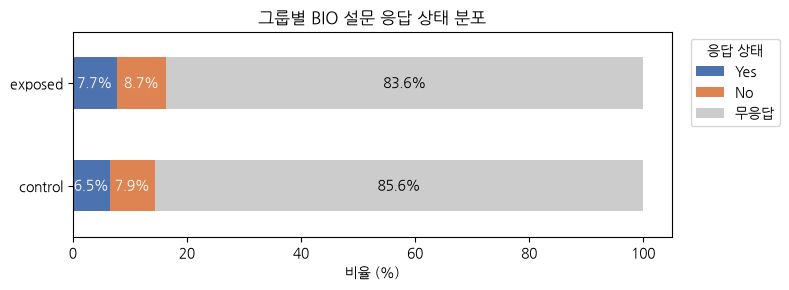

In [14]:
status = adsmart_raw.copy()
status['response_status'] = np.select(
    [status['yes']==1, status['no']==1],
    ['Yes', 'No'],
    default='무응답'
)

status_pct = pd.crosstab(status['experiment'], status['response_status'], normalize='index') * 100
status_pct = status_pct[['Yes', 'No', '무응답']]  # 순서 고정

fig, ax = plt.subplots(figsize=(8, 3))
status_pct.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#DD8452', '#CCCCCC'])

# 막대 안에 비율 텍스트 표시
for i, (idx, row) in enumerate(status_pct.iterrows()):
    cum = 0
    for col in ['Yes', 'No', '무응답']:
        val = row[col]
        if val > 3:  # 너무 작은 값은 텍스트 생략
            ax.text(cum + val/2, i, f'{val:.1f}%', va='center', ha='center', fontsize=10, color='white' if col!='무응답' else 'black')
        cum += val

ax.set_xlabel('비율 (%)')
ax.set_ylabel('')
ax.set_title('그룹별 BIO 설문 응답 상태 분포')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='응답 상태')
plt.tight_layout()
plt.show()

In [8]:
# 응답 여부 자체를 카이제곱검정으로 확인
from scipy.stats import chi2_contingency

# 교차표 생성: 그룹 x 응답여부
contingency = pd.crosstab(response_status['experiment'], response_status['responded'])
print(contingency)
print()

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("⚠️ 응답률 자체가 그룹 간에 유의미하게 다름 → MNAR 가능성, 신중한 해석 필요")
else:
    print("✅ 응답률 차이는 우연 범위 → 무응답이 그룹과 독립적일 가능성")

responded   False  True 
experiment              
control      3485    586
exposed      3349    657

카이제곱 통계량: 6.0862
p-value: 0.0136
⚠️ 응답률 자체가 그룹 간에 유의미하게 다름 → MNAR 가능성, 신중한 해석 필요


In [9]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy.stats import chi2_contingency

# --- 방법 A: 무응답 = No로 포함 (전체 8,077명 기준) ---
methodA = adsmart_raw.copy()
methodA['aware'] = methodA['yes']  # yes=1이면 인지, 나머지(no 또는 무응답)는 0

count_A = methodA.groupby('experiment')['aware'].sum() # Yes라고 응답한 사람 수
nobs_A = methodA.groupby('experiment')['aware'].count() # 그룹의 전체 인원

print("=" * 50)
print("[방법 A] 무응답 = No 포함 (전체 8,077명)")
print("=" * 50)
print(f"Control: {count_A['control']}/{nobs_A['control']} ({count_A['control']/nobs_A['control']*100:.2f}%)")
print(f"Exposed: {count_A['exposed']}/{nobs_A['exposed']} ({count_A['exposed']/nobs_A['exposed']*100:.2f}%)")

# --- 방법 B: 응답자만 (무응답 제외) ---
methodB = adsmart_raw[(adsmart_raw['yes'] == 1) | (adsmart_raw['no'] == 1)].copy() # 무응답자 제외
methodB['aware'] = methodB['yes']

count_B = methodB.groupby('experiment')['aware'].sum()
nobs_B = methodB.groupby('experiment')['aware'].count()

print()
print("=" * 50)
print("[방법 B] 응답자만 (무응답 제외)")
print("=" * 50)
print(f"Control: {count_B['control']}/{nobs_B['control']} ({count_B['control']/nobs_B['control']*100:.2f}%)")
print(f"Exposed: {count_B['exposed']}/{nobs_B['exposed']} ({count_B['exposed']/nobs_B['exposed']*100:.2f}%)")

[방법 A] 무응답 = No 포함 (전체 8,077명)
Control: 264/4071 (6.48%)
Exposed: 308/4006 (7.69%)

[방법 B] 응답자만 (무응답 제외)
Control: 264/586 (45.05%)
Exposed: 308/657 (46.88%)


In [10]:
# 두 비율 검정
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

alpha = 0.05

def run_test(count, nobs, label):
    print("=" * 55)
    print(f"[{label}]")
    print("=" * 55)
    
    count_arr = np.array([count['control'], count['exposed']])
    nobs_arr = np.array([nobs['control'], nobs['exposed']])
    
    p_control = count_arr[0] / nobs_arr[0]
    p_exposed = count_arr[1] / nobs_arr[1]
    
    print(f"Control 비율: {p_control:.4f} ({count_arr[0]}/{nobs_arr[0]})")
    print(f"Exposed 비율: {p_exposed:.4f} ({count_arr[1]}/{nobs_arr[1]})")
    print()
    
    z_stat, p_value = proportions_ztest(count_arr, nobs_arr, alternative='two-sided')
    print(f"z 통계량: {z_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value < alpha:
        print(f"→ 유의수준 {alpha}에서 귀무가설 기각: 두 그룹의 비율에 유의미한 차이 있음")
    else:
        print(f"→ 유의수준 {alpha}에서 귀무가설 기각 못함: 유의미한 차이 없음")
    print()
    
    return {'p_control': p_control, 'p_exposed': p_exposed, 'z_stat': z_stat, 'p_value': p_value}

result_A = run_test(count_A, nobs_A, "방법 A: 무응답=No 포함 (전체 기준)")
result_B = run_test(count_B, nobs_B, "방법 B: 응답자만 (무응답 제외)")

print("=" * 55)
print("[두 방법 결론 비교]")
print("=" * 55)
print(f"방법 A p-value: {result_A['p_value']:.4f} → {'유의미' if result_A['p_value'] < alpha else '유의미하지 않음'}")
print(f"방법 B p-value: {result_B['p_value']:.4f} → {'유의미' if result_B['p_value'] < alpha else '유의미하지 않음'}")

if (result_A['p_value'] < alpha) == (result_B['p_value'] < alpha):
    print("→ 두 방법의 결론 방향이 일치함 (강건한 결과)")
else:
    print("→ ⚠️ 두 방법의 결론이 갈림 (무응답 처리 방식에 따라 결론이 달라짐, 신중한 해석 필요)")

[방법 A: 무응답=No 포함 (전체 기준)]
Control 비율: 0.0648 (264/4071)
Exposed 비율: 0.0769 (308/4006)

z 통계량: -2.1083
p-value: 0.0350
→ 유의수준 0.05에서 귀무가설 기각: 두 그룹의 비율에 유의미한 차이 있음

[방법 B: 응답자만 (무응답 제외)]
Control 비율: 0.4505 (264/586)
Exposed 비율: 0.4688 (308/657)

z 통계량: -0.6457
p-value: 0.5185
→ 유의수준 0.05에서 귀무가설 기각 못함: 유의미한 차이 없음

[두 방법 결론 비교]
방법 A p-value: 0.0350 → 유의미
방법 B p-value: 0.5185 → 유의미하지 않음
→ ⚠️ 두 방법의 결론이 갈림 (무응답 처리 방식에 따라 결론이 달라짐, 신중한 해석 필요)


In [11]:
# 점 추정, 신뢰구간, 효과 크기
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import numpy as np

def cohens_h(p1, p2):
    """비율 두 개의 Cohen's h 계산 (arcsine 변환 기반)"""
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

def interpret_h(h):
    h_abs = abs(h)
    if h_abs < 0.2:
        return "매우 작음"
    elif h_abs < 0.5:
        return "작음"
    elif h_abs < 0.8:
        return "중간"
    else:
        return "큼"

def report_3set(count, nobs, label):
    print("=" * 55)
    print(f"[{label}]")
    print("=" * 55)
    
    count_arr = np.array([count['control'], count['exposed']])
    nobs_arr = np.array([nobs['control'], nobs['exposed']])
    
    p_control = count_arr[0] / nobs_arr[0]
    p_exposed = count_arr[1] / nobs_arr[1]
    
    # ① 점추정 (차이)
    diff = p_exposed - p_control
    print("① 점추정 (차이)")
    print(f"   Control 비율: {p_control:.4f} ({p_control*100:.2f}%)")
    print(f"   Exposed 비율: {p_exposed:.4f} ({p_exposed*100:.2f}%)")
    print(f"   차이 (Exposed - Control): {diff:.4f} ({diff*100:.2f}%p)")
    print()
    
    # ② 95% 신뢰구간
    ci_low, ci_upp = confint_proportions_2indep(
        count1=count_arr[1], nobs1=nobs_arr[1],
        count2=count_arr[0], nobs2=nobs_arr[0],
        method='wald'
    )
    print("② 95% 신뢰구간 (Exposed - Control)")
    print(f"   [{ci_low*100:.2f}%p, {ci_upp*100:.2f}%p]")
    if ci_low <= 0 <= ci_upp:
        print("   → 구간이 0을 포함함 → 차이가 없을 가능성도 배제 못함 (불확실성 큼)")
    else:
        print("   → 구간이 0을 포함하지 않음 → 차이가 있다고 볼 근거 있음")
    print()
    
    # ③ 효과 크기 (절대 차이 %p + 상대 차이 배수 + Cohen's h)
    relative_diff = (p_exposed - p_control) / p_control
    h = cohens_h(p_exposed, p_control)
    print("③ 효과 크기")
    print(f"   절대 차이: {diff*100:.2f}%p")
    print(f"   상대 차이: {relative_diff*100:.2f}% ({p_exposed/p_control:.2f}배)")
    print(f"   Cohen's h: {h:.4f} ({interpret_h(h)})")
    print()
    
    return {'p_control': p_control, 'p_exposed': p_exposed, 'diff': diff,
            'ci': (ci_low, ci_upp), 'relative_diff': relative_diff, 'cohens_h': h}

report_A = report_3set(count_A, nobs_A, "방법 A: 무응답=No 포함 (전체 기준)")
report_B = report_3set(count_B, nobs_B, "방법 B: 응답자만 (무응답 제외)")

[방법 A: 무응답=No 포함 (전체 기준)]
① 점추정 (차이)
   Control 비율: 0.0648 (6.48%)
   Exposed 비율: 0.0769 (7.69%)
   차이 (Exposed - Control): 0.0120 (1.20%p)

② 95% 신뢰구간 (Exposed - Control)
   [0.08%p, 2.32%p]
   → 구간이 0을 포함하지 않음 → 차이가 있다고 볼 근거 있음

③ 효과 크기
   절대 차이: 1.20%p
   상대 차이: 18.56% (1.19배)
   Cohen's h: 0.0469 (매우 작음)

[방법 B: 응답자만 (무응답 제외)]
① 점추정 (차이)
   Control 비율: 0.4505 (45.05%)
   Exposed 비율: 0.4688 (46.88%)
   차이 (Exposed - Control): 0.0183 (1.83%p)

② 95% 신뢰구간 (Exposed - Control)
   [-3.72%p, 7.38%p]
   → 구간이 0을 포함함 → 차이가 없을 가능성도 배제 못함 (불확실성 큼)

③ 효과 크기
   절대 차이: 1.83%p
   상대 차이: 4.06% (1.04배)
   Cohen's h: 0.0367 (매우 작음)



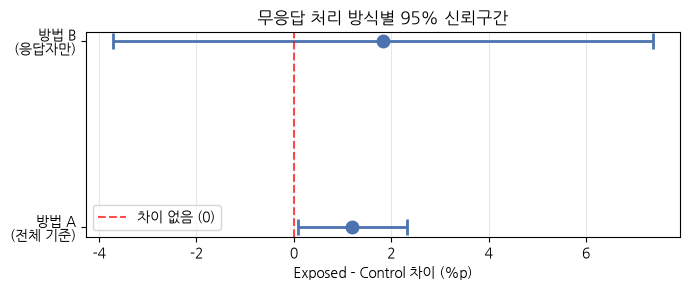

In [16]:
labels = ['방법 A\n(전체 기준)', '방법 B\n(응답자만)']
diffs = [report_A['diff']*100, report_B['diff']*100]
ci_lows = [report_A['ci'][0]*100, report_B['ci'][0]*100]
ci_upps = [report_A['ci'][1]*100, report_B['ci'][1]*100]

errors = [[d - l for d, l in zip(diffs, ci_lows)], [u - d for u, d in zip(ci_upps, diffs)]]

fig, ax = plt.subplots(figsize=(7, 3))
ax.errorbar(diffs, labels, xerr=errors, fmt='o', capsize=6, 
            color='#4C72B0', markersize=9, elinewidth=2, capthick=2)
ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='차이 없음 (0)')

ax.set_xlabel('Exposed - Control 차이 (%p)')
ax.set_title('무응답 처리 방식별 95% 신뢰구간')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 의사결정 보고서: SmartAd 브랜드 광고가 브랜드 인지도를 높이는가?

## 1. 데이터 개요

**출처**: [Kaggle - Ad A/B Testing](https://www.kaggle.com/datasets/osuolaleemmanuel/ad-ab-testing)  
**내려받은 날짜**: 2026-07-31  
**행/열**: 8,077행 × 10열

| 컬럼 | 설명 |
|---|---|
| auction_id | BIO(Brand Impact Optimiser) 설문이 노출된 사용자의 고유 ID (노출 ID). 설문을 보고도 응답하지 않으면 yes, no 모두 0으로 기록됨 |
| experiment | control(대조군: 가짜 광고 노출) / exposed(노출군: SmartAd 브랜드 인터랙티브 광고 노출) |
| date | 노출 날짜 (YYYY-MM-DD) |
| hour | 노출 시각 (HH) |
| device_make | 사용자 기기 종류 (예: Samsung) |
| platform_os | 사용자 OS ID |
| browser | BIO 설문을 확인한 브라우저 |
| yes | BIO 설문에서 "예" 라디오버튼 선택 시 1 |
| no | BIO 설문에서 "아니오" 라디오버튼 선택 시 1 |

---

## 2. 질문과 가설

**알고 싶었던 것**: 브랜드 광고 노출 여부에 따라 브랜드 인지도에 차이가 있을까?

- $p_1$ = 노출군(Exposed)의 브랜드 인지 비율 (Yes 응답 비율)
- $p_2$ = 대조군(Control)의 브랜드 인지 비율 (Yes 응답 비율)

$$H_0: p_1 = p_2 \quad \text{(광고 노출 여부에 따라 인지 비율에 차이가 없다)}$$
$$H_1: p_1 \neq p_2 \quad \text{(광고 노출 여부에 따라 인지 비율에 차이가 있다)}$$

방향을 미리 가정하지 않고, 광고가 인지도를 높이는지 낮추는지 모두 열어둔 채 차이 유무만 보수적으로 검정하기 위해 **양측검정**을 채택함.

---

## 3. 데이터 위생 점검

**기본 확인**: 결측치 없음. `experiment`, `yes`, `no` 컬럼 자료형 정상.
**중복 확인**: `auction_id` 중복 없음.

**배정 일관성**
- `experiment` 값: control(4,071) / exposed(4,006) 두 그룹 외 이상값 없음
- SRM 점검: 카이제곱검정 결과 배정 비율이 의도된 수준(50:50)과 유의미한 차이 없음 → 배정 정상

**결과 변수 품질 점검**
- yes/no 동시 1인 행: 없음 (라디오버튼 논리 일관성 확인됨)
- **무응답(yes=0, no=0) 행: 6,834건 (전체의 84.6%)** ⚠️
- 그룹별 응답률: Control 14.4% vs Exposed 16.4% → 카이제곱검정 결과 **응답률 자체가 그룹 간 유의미하게 다름 (χ²=6.09, p=0.0136)**  
  → 무응답이 처치와 무관한 MCAR이 아니라, 처치와 관련된 **MNAR(Missing Not At Random)** 가능성 시사  
  → 이후 분석을 무응답 처리 방식에 따라 두 가지로 병행: **방법 A(무응답=No로 포함, 전체 8,077명 기준)**, **방법 B(응답자만, 1,243명 기준)**

---

## 4. 검정 선택 근거

성공 지표(Yes 응답 여부)가 이분형이고 비교 집단이 2개(control, exposed)이므로 **두 비율 z검정(two-proportion z-test)**을 선택함.   카이제곱 독립성 검정과 이론적으로 동일한 결론을 내지만, 카이제곱검정은 "차이가 있다/없다"만 알려주는 반면, 두 비율 검정은 비율 차이를 직접 검정하기 때문에 비율차이의 방향과 크기, 그리고 proportion_confint로 신뢰구간까지 이어서 계산하기 편함.

---

## 5. 결과

| 지표 | 방법 A (전체 기준, n=8,077) | 방법 B (응답자만, n=1,243) |
|---|---|---|
| Control 비율 | 6.48% (264/4,071) | 45.05% (264/586) |
| Exposed 비율 | 7.69% (308/4,006) | 46.88% (308/657) |
| 점추정 (차이) | +1.20%p | +1.83%p |
| z 통계량 / p-value | -2.11 / **0.0350** | -0.65 / **0.5185** |
| 95% CI | 0을 포함하지 않음 | 0을 포함함 |
| 절대/상대 차이 | 1.20%p / 18.56% (1.19배) | 1.83%p / 4.06% (1.04배) |
| Cohen's h | 0.047 (매우 작음) | 0.037 (매우 작음) |

**핵심 발견**: 통계적 유의성은 무응답 처리 방식에 따라 갈렸으나(방법 A만 유의), **효과 크기(Cohen's h)는 두 방법 모두 일관되게 "매우 작음"**으로 나타남. 방법 A의 유의미한 차이는 순수한 인지도 효과라기보다, exposed 그룹의 더 높은 설문 응답률에서 기인했을 가능성이 있음.

---

## 6. 의사결정

### **보류 (추가 데이터 수집 및 검증 필요)**  
브랜드 광고 노출이 인지도를 높인다는 확정적인 결론을 내리기 어렵다. 즉시 출시를 결정하기보다, 아래 근거에 기반해 추가 데이터 수집 및 재검증을 권장한다.

**근거**
1. 효과 크기가 두 분석 모두에서 실질적으로 미미함 (Cohen's h < 0.05)
2. 통계적 유의성이 무응답 처리 방식에 따라 뒤집혀 결론이 불안정함
3. 응답률 자체가 그룹 간 유의미하게 달라(MNAR), 방법 A의 유의미한 결과가 "인지도 상승"이 아닌 "응답 참여 의향 상승"을 반영했을 가능성을 배제할 수 없음

**권장 조치**: 무응답을 줄이는 방향으로 설문 설계를 개선한 뒤 재실험하거나, 무응답의 원인을 파악하는 별도 조사를 선행

---

## 7. 한계

- **무응답률 84.6%로 매우 높음**: 응답자 기반 분석(방법 B)의 표본이 1,243명에 불과해 검정력이 낮고 신뢰구간이 넓음
- **MNAR 가능성**: 무응답이 처치와 관련되어 있어, 방법 A/B 어느 쪽도 편향 없는 추정치라 단정할 수 없음
- **무응답 원인 미상**: 설문 무관심, UI 문제, 광고 자체 미인지 등 원인에 따라 해석이 달라질 수 있으나 이 데이터만으로는 구분 불가
- **단일 브랜드(LUX), 단일 캠페인 기준**: 다른 브랜드·크리에이티브로 일반화 어려움